In [18]:
# ============================================================
# FASE 6 — VERIFIKASI CIFAR-COMPATIBLE RESNET
# Notebook: 03_model_verification.ipynb
# ============================================================

from google.colab import drive
from pathlib import Path
import sys
import json
import subprocess
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision


# ------------------------------------------------------------
# Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")


# ------------------------------------------------------------
# Definisikan lokasi proyek
# ------------------------------------------------------------

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/skripsi_label_noise"
)

REPO_DIR = Path(
    "/content/label-noise-thesis"
)

FIGURE_DIR = (
    PROJECT_DRIVE
    / "outputs"
    / "figures"
    / "phase_6_models"
)

TABLE_DIR = (
    PROJECT_DRIVE
    / "outputs"
    / "tables"
    / "phase_6_models"
)

MANIFEST_DIR = (
    PROJECT_DRIVE
    / "manifests"
)


# ------------------------------------------------------------
# Buat direktori output bila belum ada.
# ------------------------------------------------------------

for direktori in [
    FIGURE_DIR,
    TABLE_DIR,
    MANIFEST_DIR,
]:
    direktori.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 70)
print("PERSIAPAN FASE 6")
print("=" * 70)

print("Versi PyTorch     :", torch.__version__)
print("Versi Torchvision :", torchvision.__version__)
print("Direktori tabel   :", TABLE_DIR)
print("Direktori gambar  :", FIGURE_DIR)

print()
print("✅ Lingkungan Fase 6 siap.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PERSIAPAN FASE 6
Versi PyTorch     : 2.11.0+cpu
Versi Torchvision : 0.26.0+cpu
Direktori tabel   : /content/drive/MyDrive/skripsi_label_noise/outputs/tables/phase_6_models
Direktori gambar  : /content/drive/MyDrive/skripsi_label_noise/outputs/figures/phase_6_models

✅ Lingkungan Fase 6 siap.


In [19]:
# ============================================================
# PASTIKAN REPOSITORY TERSEDIA DI RUNTIME COLAB
# ============================================================

REPO_URL = (
    "https://github.com/luthfiaw13/"
    "label-noise-thesis.git"
)

if not REPO_DIR.exists():

    print("Repository belum tersedia di runtime.")
    print("Melakukan clone repository...")

    subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(REPO_DIR),
        ],
        check=True
    )

else:

    print("Repository sudah tersedia di runtime.")

print()
print("Lokasi repository :", REPO_DIR)

Repository sudah tersedia di runtime.

Lokasi repository : /content/label-noise-thesis


In [20]:
# ============================================================
# MEMBUAT MODUL src/models/resnet.py
# ============================================================

kode_resnet = r'''
"""
Definisi ResNet yang disesuaikan untuk citra CIFAR 32x32.

Model dibangun dari implementasi resmi torchvision:
- ResNet18
- ResNet34
- ResNet50

Perubahan yang dilakukan:
1. Tidak menggunakan pretrained weights.
2. Convolution awal diubah menjadi kernel 3x3, stride 1.
3. Initial max-pooling dihilangkan.
4. Fully-connected output disesuaikan dengan jumlah kelas.

Tujuannya adalah menggunakan stem input yang sama pada seluruh
model sehingga perbandingan kompleksitas tidak tercampur dengan
perbedaan preprocessing awal.
"""

from typing import Literal

import torch
import torch.nn as nn

from torchvision.models import (
    resnet18,
    resnet34,
    resnet50,
)


NamaModel = Literal[
    "resnet18",
    "resnet34",
    "resnet50",
]


def bangun_resnet_cifar(
    nama_model: NamaModel,
    jumlah_kelas: int = 10,
) -> nn.Module:
    """
    Membuat CIFAR-compatible ResNet.

    Parameter
    ---------
    nama_model:
        Salah satu dari:
        resnet18, resnet34, atau resnet50.

    jumlah_kelas:
        Jumlah kelas output.

    Return
    ------
    model:
        Model ResNet dengan stem yang telah disesuaikan
        untuk input CIFAR 32x32.
    """

    # --------------------------------------------------------
    # Validasi jumlah kelas.
    # --------------------------------------------------------

    if jumlah_kelas < 2:
        raise ValueError(
            "jumlah_kelas minimal harus 2."
        )


    # --------------------------------------------------------
    # Daftar builder torchvision.
    # --------------------------------------------------------

    pembuat_model = {
        "resnet18": resnet18,
        "resnet34": resnet34,
        "resnet50": resnet50,
    }


    if nama_model not in pembuat_model:
        raise ValueError(
            f"Model '{nama_model}' tidak didukung. "
            "Gunakan resnet18, resnet34, atau resnet50."
        )


    # --------------------------------------------------------
    # weights=None memastikan tidak menggunakan
    # pretrained ImageNet weights.
    # --------------------------------------------------------

    model = pembuat_model[
        nama_model
    ](
        weights=None
    )


    # --------------------------------------------------------
    # Stem CIFAR:
    #
    # Input CIFAR hanya 32x32 sehingga convolution awal
    # dibuat 3x3, stride 1 dan padding 1.
    #
    # Semua model memakai stem IDENTIK.
    # --------------------------------------------------------

    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )


    # --------------------------------------------------------
    # Max-pooling awal ImageNet dihilangkan agar feature map
    # 32x32 tidak mengalami downsampling terlalu dini.
    # --------------------------------------------------------

    model.maxpool = nn.Identity()


    # --------------------------------------------------------
    # Ubah classifier terakhir sesuai jumlah kelas dataset.
    # CIFAR-10 menggunakan 10 kelas.
    # --------------------------------------------------------

    jumlah_fitur = model.fc.in_features

    model.fc = nn.Linear(
        jumlah_fitur,
        jumlah_kelas
    )


    return model


def hitung_parameter_model(
    model: nn.Module
) -> dict:
    """
    Menghitung jumlah parameter model.

    Return
    ------
    dictionary dengan:
    - total_parameter
    - parameter_trainable
    - parameter_non_trainable
    """

    total_parameter = sum(
        parameter.numel()
        for parameter
        in model.parameters()
    )

    parameter_trainable = sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )

    parameter_non_trainable = (
        total_parameter
        -
        parameter_trainable
    )

    return {
        "total_parameter":
            int(total_parameter),

        "parameter_trainable":
            int(parameter_trainable),

        "parameter_non_trainable":
            int(parameter_non_trainable),
    }
'''

lokasi_resnet = (
    REPO_DIR
    / "src"
    / "models"
    / "resnet.py"
)

lokasi_resnet.parent.mkdir(
    parents=True,
    exist_ok=True
)

lokasi_resnet.write_text(
    kode_resnet,
    encoding="utf-8"
)

print("✅ Modul ResNet berhasil dibuat.")
print("Lokasi :", lokasi_resnet)

✅ Modul ResNet berhasil dibuat.
Lokasi : /content/label-noise-thesis/src/models/resnet.py


In [21]:
# ============================================================
# IMPORT MODUL RESNET PENELITIAN
# ============================================================

if str(REPO_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_DIR)
    )


from src.models.resnet import (
    bangun_resnet_cifar,
    hitung_parameter_model,
)


print(
    "✅ Modul CIFAR-compatible ResNet "
    "berhasil di-import."
)

✅ Modul CIFAR-compatible ResNet berhasil di-import.


In [22]:
# ============================================================
# MEMBUAT RESNET18, RESNET34, DAN RESNET50
# ============================================================

NAMA_MODEL = [
    "resnet18",
    "resnet34",
    "resnet50",
]

models = {}


# ------------------------------------------------------------
# Seed ini hanya digunakan agar inisialisasi model pada
# verifikasi dapat direproduksi.
# ------------------------------------------------------------

torch.manual_seed(17)


for nama in NAMA_MODEL:

    models[nama] = (
        bangun_resnet_cifar(
            nama_model=nama,
            jumlah_kelas=10
        )
    )

    print(
        f"✅ {nama} berhasil dibuat."
    )

✅ resnet18 berhasil dibuat.
✅ resnet34 berhasil dibuat.
✅ resnet50 berhasil dibuat.


In [23]:
# ============================================================
# VALIDASI STEM DAN CLASSIFIER
# ============================================================

print("=" * 70)
print("VALIDASI STRUKTUR MODEL")
print("=" * 70)


hasil_struktur = []


for nama, model in models.items():

    # --------------------------------------------------------
    # Ambil properti penting.
    # --------------------------------------------------------

    kernel = tuple(
        model.conv1.kernel_size
    )

    stride = tuple(
        model.conv1.stride
    )

    padding = tuple(
        model.conv1.padding
    )

    maxpool_type = (
        model.maxpool
        .__class__
        .__name__
    )

    output_class = (
        model.fc.out_features
    )

    block_type = (
        model.layer1[0]
        .__class__
        .__name__
    )


    # --------------------------------------------------------
    # Hard assertions.
    # --------------------------------------------------------

    assert kernel == (3, 3), (
        f"{nama}: kernel conv1 bukan 3x3."
    )

    assert stride == (1, 1), (
        f"{nama}: stride conv1 bukan 1."
    )

    assert padding == (1, 1), (
        f"{nama}: padding conv1 bukan 1."
    )

    assert isinstance(
        model.maxpool,
        nn.Identity
    ), (
        f"{nama}: maxpool belum dihilangkan."
    )

    assert output_class == 10, (
        f"{nama}: classifier bukan 10 kelas."
    )


    hasil_struktur.append(
        {
            "model":
                nama,

            "kernel_conv1":
                str(kernel),

            "stride_conv1":
                str(stride),

            "padding_conv1":
                str(padding),

            "maxpool":
                maxpool_type,

            "block":
                block_type,

            "jumlah_kelas_output":
                output_class,
        }
    )


df_struktur = pd.DataFrame(
    hasil_struktur
)

display(
    df_struktur
)

print()
print(
    "✅ Semua model menggunakan stem CIFAR "
    "dan classifier yang konsisten."
)

VALIDASI STRUKTUR MODEL


,model,kernel_conv1,stride_conv1,padding_conv1,maxpool,block,jumlah_kelas_output
0,resnet18,"(3, 3)","(1, 1)","(1, 1)",Identity,BasicBlock,10
1,resnet34,"(3, 3)","(1, 1)","(1, 1)",Identity,BasicBlock,10
2,resnet50,"(3, 3)","(1, 1)","(1, 1)",Identity,Bottleneck,10



✅ Semua model menggunakan stem CIFAR dan classifier yang konsisten.


In [24]:
# ============================================================
# FORWARD-PASS VALIDATION
# ============================================================

# Simulasikan batch berisi 4 citra CIFAR.
input_uji = torch.randn(
    4,
    3,
    32,
    32
)


print("=" * 70)
print("UJI FORWARD PASS")
print("=" * 70)


for nama, model in models.items():

    model.eval()

    with torch.inference_mode():

        output = model(
            input_uji
        )


    print(
        f"{nama:<10} "
        f"input={tuple(input_uji.shape)} "
        f"output={tuple(output.shape)}"
    )


    # Setiap citra harus menghasilkan 10 logits.
    assert output.shape == (
        4,
        10
    )

    # Output tidak boleh berisi NaN atau Infinity.
    assert torch.isfinite(
        output
    ).all()


print()
print(
    "✅ Seluruh model berhasil memproses "
    "input CIFAR 32x32."
)

UJI FORWARD PASS
resnet18   input=(4, 3, 32, 32) output=(4, 10)
resnet34   input=(4, 3, 32, 32) output=(4, 10)
resnet50   input=(4, 3, 32, 32) output=(4, 10)

✅ Seluruh model berhasil memproses input CIFAR 32x32.


In [25]:
# ============================================================
# MEMERIKSA UKURAN FEATURE MAP
# ============================================================

def ambil_bentuk_feature_map(
    model,
    input_tensor,
):
    """
    Menangkap ukuran tensor pada stage-stage utama ResNet.
    """

    hasil = {}

    hooks = []


    def buat_hook(
        nama_stage
    ):

        def hook(
            module,
            input_data,
            output_data
        ):

            hasil[
                nama_stage
            ] = tuple(
                output_data.shape
            )

        return hook


    modul_dipantau = {
        "conv1":
            model.conv1,

        "maxpool":
            model.maxpool,

        "layer1":
            model.layer1,

        "layer2":
            model.layer2,

        "layer3":
            model.layer3,

        "layer4":
            model.layer4,

        "avgpool":
            model.avgpool,
    }


    for nama_stage, module in (
        modul_dipantau.items()
    ):

        hooks.append(
            module.register_forward_hook(
                buat_hook(
                    nama_stage
                )
            )
        )


    model.eval()

    with torch.inference_mode():

        model(
            input_tensor
        )


    # Hapus hooks setelah selesai agar tidak menumpuk.
    for hook in hooks:
        hook.remove()


    return hasil

In [26]:
# ============================================================
# BUAT TABEL FEATURE-MAP
# ============================================================

input_satu = torch.randn(
    1,
    3,
    32,
    32
)

rekaman_feature = []


for nama, model in models.items():

    shapes = (
        ambil_bentuk_feature_map(
            model,
            input_satu
        )
    )


    for stage, shape in (
        shapes.items()
    ):

        rekaman_feature.append(
            {
                "model":
                    nama,

                "stage":
                    stage,

                "bentuk_output":
                    str(shape),

                "channel":
                    shape[1],

                "tinggi":
                    shape[-2],

                "lebar":
                    shape[-1],
            }
        )


df_feature = pd.DataFrame(
    rekaman_feature
)

display(
    df_feature
)

,model,stage,bentuk_output,channel,tinggi,lebar
0,resnet18,conv1,"(1, 64, 32, 32)",64,32,32
1,resnet18,maxpool,"(1, 64, 32, 32)",64,32,32
2,resnet18,layer1,"(1, 64, 32, 32)",64,32,32
3,resnet18,layer2,"(1, 128, 16, 16)",128,16,16
4,resnet18,layer3,"(1, 256, 8, 8)",256,8,8
5,resnet18,layer4,"(1, 512, 4, 4)",512,4,4
6,resnet18,avgpool,"(1, 512, 1, 1)",512,1,1
7,resnet34,conv1,"(1, 64, 32, 32)",64,32,32
8,resnet34,maxpool,"(1, 64, 32, 32)",64,32,32
9,resnet34,layer1,"(1, 64, 32, 32)",64,32,32


In [27]:
# ============================================================
# HITUNG KOMPLEKSITAS BERDASARKAN PARAMETER
# ============================================================

rekaman_kompleksitas = []


for nama, model in models.items():

    info = hitung_parameter_model(
        model
    )

    block_type = (
        model.layer1[0]
        .__class__
        .__name__
    )


    rekaman_kompleksitas.append(
        {
            "model":
                nama,

            "block":
                block_type,

            "total_parameter":
                info[
                    "total_parameter"
                ],

            "parameter_trainable":
                info[
                    "parameter_trainable"
                ],

            "parameter_juta":
                (
                    info[
                        "total_parameter"
                    ]
                    / 1_000_000
                ),
        }
    )


df_complexity = pd.DataFrame(
    rekaman_kompleksitas
)


# ------------------------------------------------------------
# Complexity minimal harus meningkat berdasarkan parameter.
# ------------------------------------------------------------

parameter_values = (
    df_complexity[
        "total_parameter"
    ].values
)

assert (
    parameter_values[0]
    <
    parameter_values[1]
    <
    parameter_values[2]
), (
    "Urutan jumlah parameter RN18 < RN34 < RN50 "
    "tidak terpenuhi."
)


print("=" * 70)
print("RINGKASAN JUMLAH PARAMETER")
print("=" * 70)

display(
    df_complexity
)

print()
print(
    "✅ Jumlah parameter meningkat dari "
    "ResNet18 → ResNet34 → ResNet50."
)

RINGKASAN JUMLAH PARAMETER


,model,block,total_parameter,parameter_trainable,parameter_juta
0,resnet18,BasicBlock,11173962,11173962,11.173962
1,resnet34,BasicBlock,21282122,21282122,21.282122
2,resnet50,Bottleneck,23520842,23520842,23.520842



✅ Jumlah parameter meningkat dari ResNet18 → ResNet34 → ResNet50.


In [28]:
# ============================================================
# ESTIMASI FLOPS FORWARD PASS
# ============================================================

from torch.profiler import (
    profile,
    ProfilerActivity,
)


def estimasi_flops_forward(
    model
):
    """
    Mengestimasi FLOPs untuk satu forward pass
    dengan input 1 x 3 x 32 x 32.

    Catatan:
    torch.profiler menghitung FLOPs untuk operator
    yang didukung, sehingga nilai ini diperlakukan
    sebagai estimasi kompleksitas komputasi.
    """

    # Salin model agar proses profiling tidak mengubah
    # model utama yang sedang diverifikasi.
    model_cpu = copy.deepcopy(
        model
    ).cpu()

    model_cpu.eval()


    input_cpu = torch.randn(
        1,
        3,
        32,
        32
    )


    with torch.inference_mode():

        with profile(
            activities=[
                ProfilerActivity.CPU
            ],
            record_shapes=True,
            with_flops=True,
        ) as profiler:

            model_cpu(
                input_cpu
            )


    total_flops = 0


    for event in (
        profiler.key_averages()
    ):

        if event.flops:

            total_flops += (
                event.flops
            )


    return int(
        total_flops
    )

In [29]:
# ============================================================
# PROFILING SELURUH MODEL
# ============================================================

flops_records = []


print("=" * 70)
print("ESTIMASI FLOPS MODEL")
print("=" * 70)


for nama, model in models.items():

    print(
        f"Menghitung estimasi FLOPs {nama}..."
    )

    flops = (
        estimasi_flops_forward(
            model
        )
    )


    flops_records.append(
        {
            "model":
                nama,

            "estimasi_flops":
                flops,

            "estimasi_gflops":
                flops / 1_000_000_000,
        }
    )


df_flops = pd.DataFrame(
    flops_records
)


df_complexity = (
    df_complexity.merge(
        df_flops,
        on="model",
        how="left"
    )
)


display(
    df_complexity
)

print()
print(
    "✅ Estimasi komputasi model berhasil dihitung."
)

ESTIMASI FLOPS MODEL
Menghitung estimasi FLOPs resnet18...
Menghitung estimasi FLOPs resnet34...
Menghitung estimasi FLOPs resnet50...


,model,block,total_parameter,parameter_trainable,parameter_juta,estimasi_flops,estimasi_gflops
0,resnet18,BasicBlock,11173962,11173962,11.173962,1110845440,1.110845
1,resnet34,BasicBlock,21282122,21282122,21.282122,2318804992,2.318805
2,resnet50,Bottleneck,23520842,23520842,23.520842,2595659776,2.595660



✅ Estimasi komputasi model berhasil dihitung.


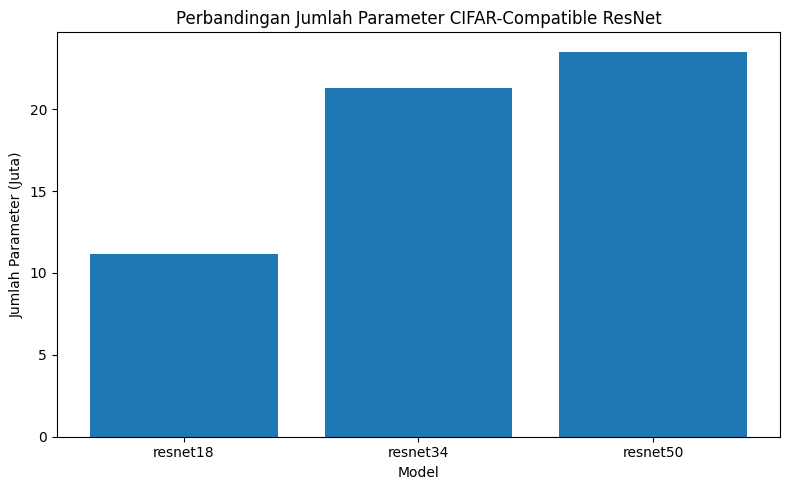

✅ Visualisasi parameter tersimpan:
/content/drive/MyDrive/skripsi_label_noise/outputs/figures/phase_6_models/perbandingan_parameter_resnet.png


In [30]:
# ============================================================
# VISUALISASI JUMLAH PARAMETER
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    df_complexity[
        "model"
    ],
    df_complexity[
        "parameter_juta"
    ]
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Jumlah Parameter (Juta)"
)

plt.title(
    "Perbandingan Jumlah Parameter "
    "CIFAR-Compatible ResNet"
)

plt.tight_layout()


lokasi_gambar_parameter = (
    FIGURE_DIR
    / "perbandingan_parameter_resnet.png"
)

plt.savefig(
    lokasi_gambar_parameter,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Visualisasi parameter tersimpan:"
)

print(
    lokasi_gambar_parameter
)

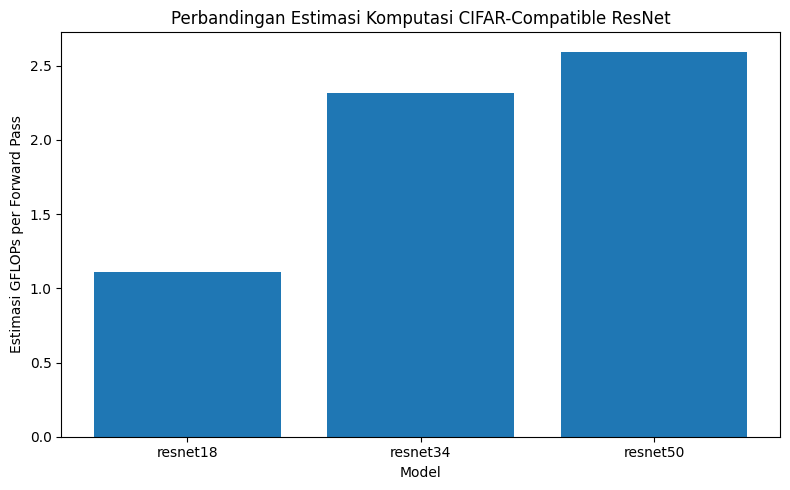

✅ Visualisasi FLOPs tersimpan:
/content/drive/MyDrive/skripsi_label_noise/outputs/figures/phase_6_models/perbandingan_flops_resnet.png


In [31]:
# ============================================================
# VISUALISASI ESTIMASI FLOPS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    df_complexity[
        "model"
    ],
    df_complexity[
        "estimasi_gflops"
    ]
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Estimasi GFLOPs per Forward Pass"
)

plt.title(
    "Perbandingan Estimasi Komputasi "
    "CIFAR-Compatible ResNet"
)

plt.tight_layout()


lokasi_gambar_flops = (
    FIGURE_DIR
    / "perbandingan_flops_resnet.png"
)

plt.savefig(
    lokasi_gambar_flops,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Visualisasi FLOPs tersimpan:"
)

print(
    lokasi_gambar_flops
)

In [32]:
# ============================================================
# SIMPAN TABEL HASIL FASE 6
# ============================================================

lokasi_tabel_kompleksitas = (
    TABLE_DIR
    / "model_complexity_summary.csv"
)

lokasi_tabel_struktur = (
    TABLE_DIR
    / "model_structure_summary.csv"
)

lokasi_tabel_feature = (
    TABLE_DIR
    / "model_feature_map_summary.csv"
)


df_complexity.to_csv(
    lokasi_tabel_kompleksitas,
    index=False
)

df_struktur.to_csv(
    lokasi_tabel_struktur,
    index=False
)

df_feature.to_csv(
    lokasi_tabel_feature,
    index=False
)


print("✅ Seluruh tabel Fase 6 berhasil disimpan.")

print()
print(
    "Kompleksitas :",
    lokasi_tabel_kompleksitas
)

print(
    "Struktur     :",
    lokasi_tabel_struktur
)

print(
    "Feature map  :",
    lokasi_tabel_feature
)

✅ Seluruh tabel Fase 6 berhasil disimpan.

Kompleksitas : /content/drive/MyDrive/skripsi_label_noise/outputs/tables/phase_6_models/model_complexity_summary.csv
Struktur     : /content/drive/MyDrive/skripsi_label_noise/outputs/tables/phase_6_models/model_structure_summary.csv
Feature map  : /content/drive/MyDrive/skripsi_label_noise/outputs/tables/phase_6_models/model_feature_map_summary.csv


In [33]:
# ============================================================
# MEMBUAT MODEL MANIFEST
# ============================================================

manifest_model = {

    "fase":
        "FASE_6_MODEL_VERIFICATION",

    "keluarga_model":
        "Torchvision ResNet",

    "model": [
        "resnet18",
        "resnet34",
        "resnet50"
    ],

    "pretrained_weights":
        False,

    "weights_argument":
        None,

    "input_shape":
        [
            3,
            32,
            32
        ],

    "jumlah_kelas":
        10,

    "stem": {

        "conv_kernel":
            "3x3",

        "conv_stride":
            1,

        "conv_padding":
            1,

        "initial_maxpool":
            False,
    },

    "complexity_definition": {

        "model_variant":
            True,

        "block_type":
            True,

        "parameter_count":
            True,

        "flops":
            (
                "Estimasi torch.profiler "
                "pada forward pass 1x3x32x32"
            ),
    },

    "model_records":
        df_complexity.to_dict(
            orient="records"
        ),

    "status":
        "VERIFIED",
}


lokasi_manifest_model = (
    MANIFEST_DIR
    / "model_manifest.json"
)


with open(
    lokasi_manifest_model,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        manifest_model,
        file,
        indent=4
    )


print(
    "✅ Model manifest berhasil disimpan:"
)

print(
    lokasi_manifest_model
)

✅ Model manifest berhasil disimpan:
/content/drive/MyDrive/skripsi_label_noise/manifests/model_manifest.json


In [34]:
# ============================================================
# LAPORAN VALIDASI AKHIR FASE 6
# ============================================================

checks = {

    "ResNet18 tersedia":
        "resnet18" in models,

    "ResNet34 tersedia":
        "resnet34" in models,

    "ResNet50 tersedia":
        "resnet50" in models,

    "semua menggunakan conv1 3x3":
        all(
            tuple(
                model.conv1.kernel_size
            )
            ==
            (3, 3)

            for model
            in models.values()
        ),

    "semua menggunakan stride 1":
        all(
            tuple(
                model.conv1.stride
            )
            ==
            (1, 1)

            for model
            in models.values()
        ),

    "semua initial maxpool dihilangkan":
        all(
            isinstance(
                model.maxpool,
                nn.Identity
            )

            for model
            in models.values()
        ),

    "semua classifier memiliki 10 output":
        all(
            model.fc.out_features
            ==
            10

            for model
            in models.values()
        ),

    "jumlah parameter meningkat RN18-RN34-RN50":
        (
            parameter_values[0]
            <
            parameter_values[1]
            <
            parameter_values[2]
        ),

    "estimasi FLOPs berhasil diperoleh":
        all(
            nilai > 0

            for nilai
            in df_complexity[
                "estimasi_flops"
            ]
        ),

    "tabel kompleksitas tersimpan":
        lokasi_tabel_kompleksitas.exists(),

    "model manifest tersimpan":
        lokasi_manifest_model.exists(),

    "visualisasi parameter tersimpan":
        lokasi_gambar_parameter.exists(),

    "visualisasi FLOPs tersimpan":
        lokasi_gambar_flops.exists(),
}


print("=" * 70)
print("FASE 6 — LAPORAN VALIDASI AKHIR")
print("=" * 70)


semua_lulus = True


for nama_check, status in (
    checks.items()
):

    simbol = (
        "✅"
        if status
        else "❌"
    )

    print(
        f"{simbol} {nama_check}"
    )

    if not status:

        semua_lulus = False


print()


if semua_lulus:

    print("=" * 70)
    print(
        "FASE 6 CIFAR-COMPATIBLE RESNET BERHASIL"
    )
    print("=" * 70)

else:

    raise RuntimeError(
        "FASE 6 belum lolos seluruh validasi. "
        "Jangan lanjut ke training."
    )

FASE 6 — LAPORAN VALIDASI AKHIR
✅ ResNet18 tersedia
✅ ResNet34 tersedia
✅ ResNet50 tersedia
✅ semua menggunakan conv1 3x3
✅ semua menggunakan stride 1
✅ semua initial maxpool dihilangkan
✅ semua classifier memiliki 10 output
✅ jumlah parameter meningkat RN18-RN34-RN50
✅ estimasi FLOPs berhasil diperoleh
✅ tabel kompleksitas tersimpan
✅ model manifest tersimpan
✅ visualisasi parameter tersimpan
✅ visualisasi FLOPs tersimpan

FASE 6 CIFAR-COMPATIBLE RESNET BERHASIL


In [37]:
# ============================================================
# COMMIT FASE 6 — CIFAR-COMPATIBLE RESNET
# File yang dikomit:
# src/models/resnet.py
# ============================================================

from pathlib import Path
from google.colab import userdata
import subprocess
import os
import tempfile


# ------------------------------------------------------------
# 1. Konfigurasi repository
# ------------------------------------------------------------

REPO_DIR = Path(
    "/content/label-noise-thesis"
)

FILE_TARGET = (
    REPO_DIR
    / "src"
    / "models"
    / "resnet.py"
)

GITHUB_USERNAME = "luthfiaw13"

REMOTE_URL = (
    "https://github.com/"
    "luthfiaw13/"
    "label-noise-thesis.git"
)


# ------------------------------------------------------------
# 2. Pastikan repository dan file tersedia
# ------------------------------------------------------------

if not REPO_DIR.exists():
    raise FileNotFoundError(
        "Repository tidak ditemukan di /content/label-noise-thesis."
    )

if not FILE_TARGET.exists():
    raise FileNotFoundError(
        "File src/models/resnet.py tidak ditemukan."
    )


print("=" * 70)
print("COMMIT FASE 6 — CIFAR-COMPATIBLE RESNET")
print("=" * 70)

print(
    "Repository :",
    REPO_DIR
)

print(
    "File target:",
    FILE_TARGET
)


# ------------------------------------------------------------
# 3. Pastikan remote GitHub menggunakan URL aman
#    tanpa Personal Access Token.
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "remote",
        "set-url",
        "origin",
        REMOTE_URL,
    ],
    check=True,
)


# ------------------------------------------------------------
# 4. Tampilkan status Git SEBELUM staging
# ------------------------------------------------------------

status_awal = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)


print()
print("=" * 70)
print("STATUS GIT SEBELUM COMMIT")
print("=" * 70)

if status_awal.stdout.strip():

    print(
        status_awal.stdout
    )

else:

    print(
        "Tidak ada perubahan yang terdeteksi."
    )


# ------------------------------------------------------------
# 5. Stage HANYA src/models/resnet.py
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        "src/models/resnet.py",
    ],
    check=True,
)


# ------------------------------------------------------------
# 6. Periksa isi staging area
# ------------------------------------------------------------

staged_files = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "diff",
        "--cached",
        "--name-only",
    ],
    capture_output=True,
    text=True,
    check=True,
)


print()
print("=" * 70)
print("FILE YANG AKAN DI-COMMIT")
print("=" * 70)

print(
    staged_files.stdout
)


# ------------------------------------------------------------
# 7. Pastikan hanya resnet.py yang masuk staging
# ------------------------------------------------------------

daftar_file = [
    item.strip()
    for item
    in staged_files.stdout.splitlines()
    if item.strip()
]


if len(daftar_file) == 0:

    print(
        "ℹ️ Tidak ada perubahan baru pada src/models/resnet.py."
    )

    print(
        "Kemungkinan file tersebut sudah pernah di-commit."
    )

    commit_dibuat = False

else:

    if daftar_file != [
        "src/models/resnet.py"
    ]:

        raise RuntimeError(
            "Staging area berisi file selain "
            "src/models/resnet.py. Commit dibatalkan."
        )


    # --------------------------------------------------------
    # 8. Buat commit
    # --------------------------------------------------------

    hasil_commit = subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "commit",
            "-m",
            (
                "Implement and verify "
                "CIFAR-compatible ResNet models"
            ),
        ],
        capture_output=True,
        text=True,
    )


    if hasil_commit.returncode != 0:

        print(
            hasil_commit.stdout
        )

        print(
            hasil_commit.stderr
        )

        raise RuntimeError(
            "Commit gagal dibuat."
        )


    print()
    print("=" * 70)
    print("HASIL COMMIT")
    print("=" * 70)

    print(
        hasil_commit.stdout
    )

    print(
        "✅ Commit Fase 6 berhasil dibuat."
    )

    commit_dibuat = True


# ------------------------------------------------------------
# 9. Ambil GitHub Personal Access Token dari Colab Secrets
# ------------------------------------------------------------

token = userdata.get(
    "GITHUB_TOKEN"
)

if not token:
    raise RuntimeError(
        "GITHUB_TOKEN tidak ditemukan di Colab Secrets."
    )


# ------------------------------------------------------------
# 10. Buat temporary GIT_ASKPASS.
#
#     Cara ini menjaga Personal Access Token agar tidak
#     ditulis langsung ke URL remote repository.
# ------------------------------------------------------------

askpass_script = """#!/bin/sh
case "$1" in
    *Username*)
        echo "$GIT_USERNAME"
        ;;
    *Password*)
        echo "$GIT_TOKEN"
        ;;
esac
"""


with tempfile.NamedTemporaryFile(
    mode="w",
    delete=False,
    suffix=".sh"
) as file:

    file.write(
        askpass_script
    )

    askpass_path = file.name


os.chmod(
    askpass_path,
    0o700
)


# ------------------------------------------------------------
# 11. Siapkan environment autentikasi GitHub
# ------------------------------------------------------------

env_git = os.environ.copy()

env_git[
    "GIT_ASKPASS"
] = askpass_path

env_git[
    "GIT_TERMINAL_PROMPT"
] = "0"

env_git[
    "GIT_USERNAME"
] = GITHUB_USERNAME

env_git[
    "GIT_TOKEN"
] = token


# ------------------------------------------------------------
# 12. Push branch main ke GitHub
# ------------------------------------------------------------

try:

    hasil_push = subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "push",
            "origin",
            "main",
        ],
        capture_output=True,
        text=True,
        env=env_git,
    )

finally:

    # --------------------------------------------------------
    # Hapus temporary authentication script.
    # --------------------------------------------------------

    if os.path.exists(
        askpass_path
    ):

        os.remove(
            askpass_path
        )


if hasil_push.returncode != 0:

    print()
    print(
        hasil_push.stderr
    )

    raise RuntimeError(
        "Push ke GitHub gagal."
    )


print()
print("=" * 70)
print("HASIL PUSH")
print("=" * 70)

if hasil_push.stdout.strip():

    print(
        hasil_push.stdout
    )

if hasil_push.stderr.strip():

    print(
        hasil_push.stderr
    )


# ------------------------------------------------------------
# 13. Ambil commit SHA terbaru
# ------------------------------------------------------------

commit_sha = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


# ------------------------------------------------------------
# 14. Tampilkan status akhir repository
# ------------------------------------------------------------

status_akhir = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)


print()
print("=" * 70)
print("COMMIT FASE 6 SELESAI")
print("=" * 70)

print(
    "Commit SHA terbaru:",
    commit_sha
)

print(
    "File yang dibekukan :",
    "src/models/resnet.py"
)

print(
    "Branch              :",
    "main"
)

print()


if status_akhir.stdout.strip():

    print(
        "Catatan: masih terdapat perubahan lokal lain "
        "yang TIDAK dimasukkan ke commit ini:"
    )

    print()

    print(
        status_akhir.stdout
    )

else:

    print(
        "✅ Working tree bersih."
    )


print()
print(
    "✅ src/models/resnet.py berhasil diamankan di GitHub."
)

COMMIT FASE 6 — CIFAR-COMPATIBLE RESNET
Repository : /content/label-noise-thesis
File target: /content/label-noise-thesis/src/models/resnet.py

STATUS GIT SEBELUM COMMIT
Tidak ada perubahan yang terdeteksi.

FILE YANG AKAN DI-COMMIT

ℹ️ Tidak ada perubahan baru pada src/models/resnet.py.
Kemungkinan file tersebut sudah pernah di-commit.

HASIL PUSH
To https://github.com/luthfiaw13/label-noise-thesis.git
   2e3bc4f..ca4896a  main -> main


COMMIT FASE 6 SELESAI
Commit SHA terbaru: ca4896a498b3b374c17e5ae30adfc2adb08c35fa
File yang dibekukan : src/models/resnet.py
Branch              : main

✅ Working tree bersih.

✅ src/models/resnet.py berhasil diamankan di GitHub.
